In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import kagglehub


path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [3]:
import os

os.listdir('/kaggle/input/insurance')

['insurance.csv']

In [6]:
import pandas as pd
import seaborn as sns


In [9]:
insurance_data=pd.read_csv("/kaggle/input/insurance/insurance.csv")

In [11]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

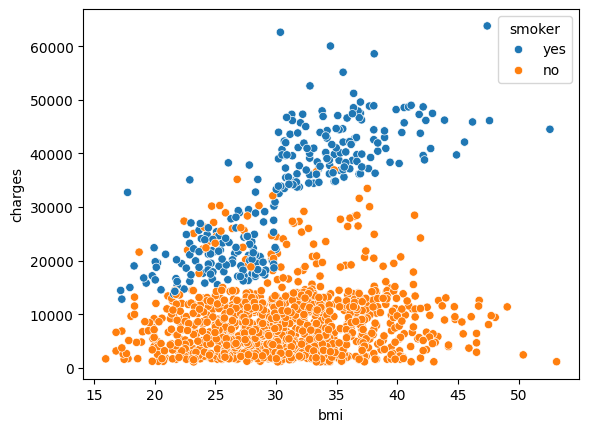

In [14]:
sns.scatterplot(x=insurance_data["bmi"],y=insurance_data["charges"],hue=insurance_data["smoker"])

In [16]:
X=insurance_data.drop(columns=["charges","region"])
y=insurance_data["charges"]

In [17]:
X.head()

,age,sex,bmi,children,smoker
0,19,female,27.900,0,yes
1,18,male,33.770,1,no
2,28,male,33.000,3,no
3,33,male,22.705,0,no
4,32,male,28.880,0,no


In [19]:
X["sex"]=X["sex"].map({"male":0,"female":1})
X["smoker"]=X["smoker"].map({"no":0,"yes":1})

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [22]:
from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)



LinearRegression()

In [23]:
y_pred=model.predict(X_test)
from sklearn.metrics import r2_score

r2=r2_score(y_test, y_pred)
print(r2)

0.7811302113434095


In [25]:
n=X_test.shape[0]
p=X_test.shape[1]

adj_r2=1-((1-r2)*(n-1))/(n-p-1)
print(adj_r2)

0.7769533069797342


In [37]:
X=insurance_data.drop(columns=["charges"])
y=insurance_data["charges"]

pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int)
X["sex"]=X["sex"].map({"male":0,"female":1})
X["smoker"]=X["smoker"].map({"no":0,"yes":1})
# Create interaction features
X["age_smoker"] = X["age"] * X["smoker"]
X["bmi_smoker"] = X["bmi"] * X["smoker"]


In [38]:
X.head()

,age,sex,bmi,children,smoker,region,age_smoker,bmi_smoker
0,19,1,27.900,0,1,southwest,19,27.9
1,18,0,33.770,1,0,southeast,0,0.0
2,28,0,33.000,3,0,southeast,0,0.0
3,33,0,22.705,0,0,northwest,0,0.0
4,32,0,28.880,0,0,northwest,0,0.0


In [39]:
X = pd.get_dummies(X, columns=["region"], dtype=int)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
from sklearn.metrics import r2_score
r2=r2_score(y_test, y_pred)
print(r2)

0.865231697953168


In [40]:

# Training prediction
y_train_pred = model.predict(X_train)
r2_train = r2_score(y_train, y_train_pred)

# Testing prediction
y_test_pred = model.predict(X_test)
r2_test = r2_score(y_test, y_test_pred)

print("Training data R²:", r2_train)
print("Testing data R²:", r2_test)

Training data R²: 0.8340713711218875
Testing data R²: 0.865231697953168
